In [50]:
#!/usr/bin/env python3
import numpy as np
import nibabel as nib
from pathlib import Path
import scipy.stats

bold_path = Path("/juice6/u/nlp/climblab/BIDS/moth/derivatives/preprocess/main/sub-UTS01/ses-2/func/sub-UTS01_ses-2_task-legacy_space-T1w_desc-preproc_bold.nii.gz")
ic_path   = Path("/juice6/u/nlp/climblab/BIDS/moth/derivatives/ica/fsnative/node-session/sub-UTS01/ses-2/melodic/melodic_IC.nii.gz")
out_path  = Path("/juice6/u/nlp/climblab/BIDS/moth/derivatives/ica/test_projection_clean.nii.gz")
signals_path = Path("/juice6/u/nlp/climblab/BIDS/moth/derivatives/ica/fsnative/node-session/sub-UTS01/ses-2/signals.txt")

# ---- Load data (float32 to keep memory reasonable) ----
bold_img = nib.load(str(bold_path))
bold     = bold_img.get_fdata(dtype=np.float32)     # shape: (X,Y,Z,T)
aff      = bold_img.affine
hdr      = bold_img.header.copy()
X, Y, Z, T = bold.shape

ic_img = nib.load(str(ic_path))
ics    = ic_img.get_fdata(dtype=np.float32)         # shape: (X,Y,Z,K)
if ics.ndim != 4:
    raise ValueError("melodic_IC should be 4D (X,Y,Z,K)")
if ics.shape[:3] != (X, Y, Z):
    raise ValueError("melodic_IC spatial dims do not match run_1")

K = ics.shape[3]

# ---- Reshape to 2D matrices: voxels x time/components ----
Ymat = bold.reshape(-1, T)       # (V, T)
Amat = ics.reshape(-1, K)        # (V, K)
V = Amat.shape[0]

#normalize bold
Ymat[np.isnan(Ymat)]=0
Ymat = scipy.stats.zscore(Ymat, axis=1)
Ymat[np.isnan(Ymat)]=0

#select only signal ICs
signals = np.loadtxt(str(signals_path)).astype(np.int32)
Amat = Amat[:,signals-1]

# ---- Compute least-squares projection using pseudoinverse ----
# We avoid forming the huge projection matrix P = A(A^T A)^{-1}A^T.
# Instead: C = A^+ Y, then Y_hat = A C.
A_pinv = np.linalg.pinv(Amat, rcond=1e-6)   # (K[+1], Vm) -> actually (K[+1], Vm) since Am is (Vm, K[+1])
C      = A_pinv @ Ymat                      # (K[+1], T)
Yhat_m = Amat @ C                           # (Vm, T)

# ---- Stitch back into full volume and save ----
Yhat_4d = Yhat_m.reshape(X, Y, Z, T)
clean_img = nib.Nifti1Image(Yhat_4d, affine=aff, header=hdr)
clean_img.to_filename(str(out_path))
print(f"Wrote denoised series (projection onto ICA subspace) to: {out_path}")


Wrote denoised series (projection onto ICA subspace) to: /juice6/u/nlp/climblab/BIDS/moth/derivatives/ica/test_projection_clean.nii.gz


In [54]:
tmp = np.arange(0,10)
tmp = tmp[0:20]
print(tmp)

[0 1 2 3 4 5 6 7 8 9]


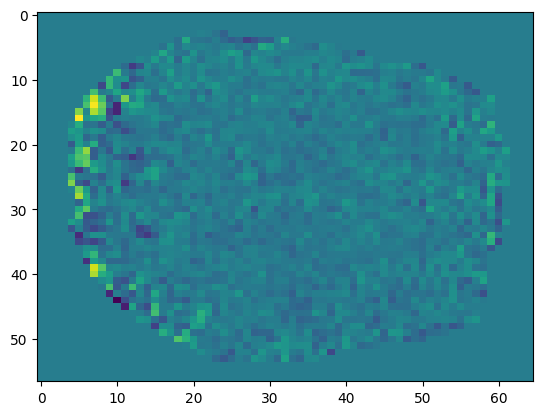

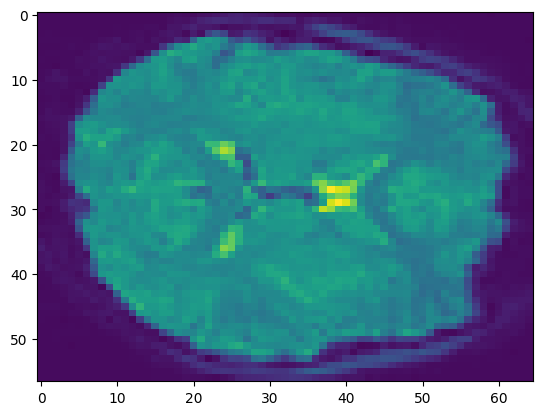

In [44]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(ics[:,:,30,0], aspect='auto')
plt.show()

plt.figure()
plt.imshow(bold[:,:,30,0], aspect='auto')
plt.show()

In [53]:
signals_path = Path("/juice6/u/nlp/climblab/BIDS/moth/derivatives/ica/fsnative/node-subject/sub-UTS01/signals.txt")
sig = np.loadtxt(str(signals_path))
print(len(sig))

88
